Imports go at the top!


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array
from PIL import Image, ImageOps

In [ ]:
data_dir = "/content/drive/MyDrive/open_closed_hand"

train = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=(180, 180),
    batch_size=1,
    validation_split=0.2,
    subset="training",
    seed=123
)

val = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=(180, 180),
    batch_size=1,
    validation_split=0.2,
    subset="validation",
    seed=123
)

Found 100 files belonging to 2 classes.
Using 80 files for training.
Found 100 files belonging to 2 classes.
Using 20 files for validation.


In [ ]:
class_names = ['open hand', 'closed hand']
print("Classes:", class_names)

Classes: ['open hand', 'closed hand']


In [ ]:
model = tf.keras.Sequential([
    layers.Rescaling(1./255, input_shape=(180, 180, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.Conv2D(16, 3, activation="relu"),

    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation="relu"),

    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),

    layers.Dropout(0.1),
    layers.Dense(2, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer="Adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])
model.fit(train, validation_data=val, epochs=10)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 24s 262ms/step - accuracy: 0.4875 - loss: 1.0350 - val_accuracy: 0.5000 - val_loss: 0.6908
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 138ms/step - accuracy: 0.5500 - loss: 0.6969 - val_accuracy: 0.8000 - val_loss: 0.6680
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 18s 107ms/step - accuracy: 0.5500 - loss: 0.6898 - val_accuracy: 0.8000 - val_loss: 0.6288
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - accuracy: 0.6500 - loss: 0.6588 - val_accuracy: 0.7000 - val_loss: 0.5465
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 136ms/step - accuracy: 0.7500 - loss: 0.5817 - val_accuracy: 0.6500 - val_loss: 0.5678
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.8250 - loss: 0.5979 - val_accuracy: 0.7000 - val_loss: 0.6234
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 126ms/step - accuracy: 0.6250 - loss: 0.7468 - val_accuracy: 0.8000 - val_loss: 0.6214
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 131ms/step - accuracy: 0.7750 - loss: 0.5812 - val_accura

In [ ]:
uploaded = files.upload()

for file_name in uploaded.keys():
  img = load_img(file_name, target_size=(180, 180))
  img = img.convert('RGB')
  img = ImageOps.exif_transpose(img)
  img_array = img_to_array(img)
  img_array = tf.expand_dims(img_array, 0)

predictions = model.predict(img_array)[0]


Saving IMG_1359.JPG to IMG_1359.JPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


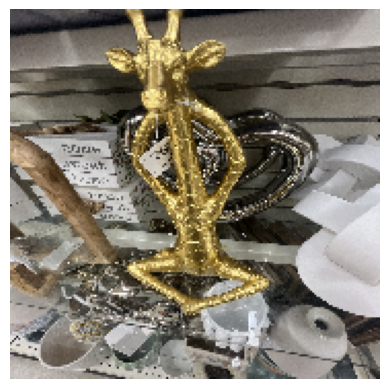

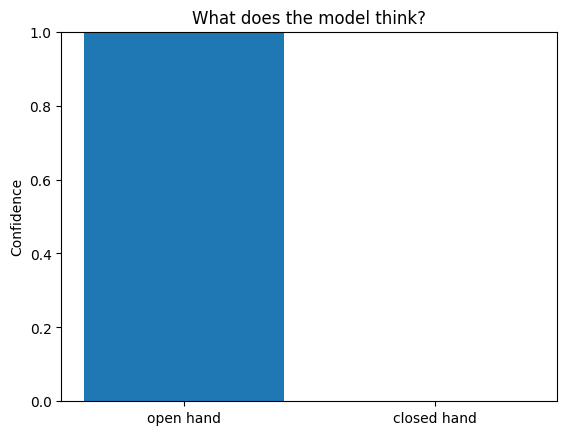

open hand: 100.0%
closed hand: 0.0%


In [ ]:
plt.imshow(img)
plt.axis("off")
plt.show()

plt.bar(class_names, predictions)
plt.ylim(0, 1)
plt.title("What does the model think?")
plt.ylabel("Confidence")
plt.show()

for name, confidence in zip(class_names, predictions):
    print(f"{name}: {confidence * 100:.1f}%")